## Lab: Intro. ANN, MNIST Model + Deploy with Streamlit

- รหัสนิสิต:67102010511
- ชื่อ - นามสกุล: ณธรรม ชาติสุวรรณ



- Google sheet link: https://docs.google.com/spreadsheets/d/1bFuB14t3cr1AyMbG2hK5cIx6OfT8NRPbIkPEHRZh6wo/edit?usp=sharing
- GitHub Repo link: https://github.com/nathamchatsuwan-lang/CP461
- Your MNIST App:


ส่งเป็น link folder week6-ANN-MNIST-Deploy-6xxx ที่ประกอบด้วย
- Intro-ANN-MNIST-6xxxx.ipynb
- app.py
- 6xxxx_mnist_model.keras
- requirements.txt

### 0. Create venv & Install packages (กรณีที่จะทำบนเครื่องตนเอง)

VS Code --> Terminal > New Terminal

python -m venv ann-venv

ann-venv\Scripts\activate

pip list

pip install ipykernel

pip install tensorflow scikit-learn pandas matplotlib joblib

### 0. Mount Deive

ปรับ path ตามของตนเอง

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
cd /content/drive/MyDrive/CP461/week6-ANN-MNIST-Deploy-67102010511

/content/drive/MyDrive/CP461/week6-ANN-MNIST-Deploy-67102010511


In [64]:
ls

67102010511_mnist_model.keras  img_1.jpg                  requirements.txt
app.py                         Intro-ANN-MNIST-std.ipynb  RubricsLabNN.pdf


### 1. Import TensorFlow and Keras:

In [80]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


### 2. Load and Prepare Data (MNIST):

In [66]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

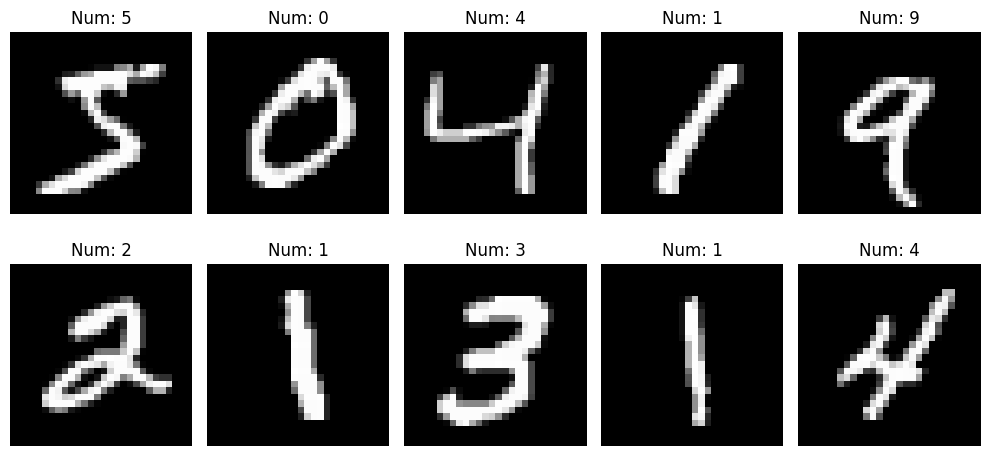

In [67]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Num: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Define the Model Architecture (Sequential API):

In [68]:
model = keras.Sequential([
	# Flatten 28x28 image to 784-element vector
	keras.Input(shape=(28, 28)),
	layers.Flatten(),

	# Hidden Layer 1: 128 neurons, ReLU activation
	layers.Dense(128, activation="relu"),

	# Output Layer: 10 neurons, Softmax activation
	layers.Dense(10, activation="softmax")
])

In [69]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile the Model:

In [70]:
model.compile(
	optimizer="adam",
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"]
)

### 5. Train the Model (the \texttt{fit} function):

In [71]:
history = model.fit(
		x_train,
		y_train,
		epochs=5,
		batch_size=32,
		validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9181 - loss: 0.2859 - val_accuracy: 0.9582 - val_loss: 0.1500
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9627 - loss: 0.1253 - val_accuracy: 0.9663 - val_loss: 0.1130
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9736 - loss: 0.0853 - val_accuracy: 0.9684 - val_loss: 0.1092
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9814 - loss: 0.0632 - val_accuracy: 0.9697 - val_loss: 0.1044
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9858 - loss: 0.0484 - val_accuracy: 0.9727 - val_loss: 0.0928


### 6. Evaluate the Model:

In [78]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc}")

313/313 - 1s - 2ms/step - accuracy: 0.9740 - loss: 0.0881

Test accuracy: 0.9739999771118164


### 7. Plot Training History:

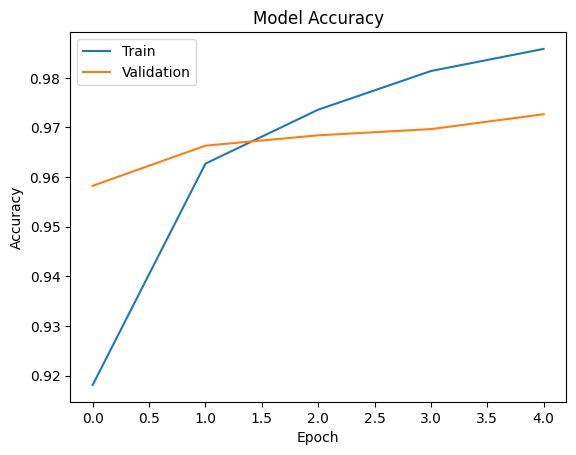

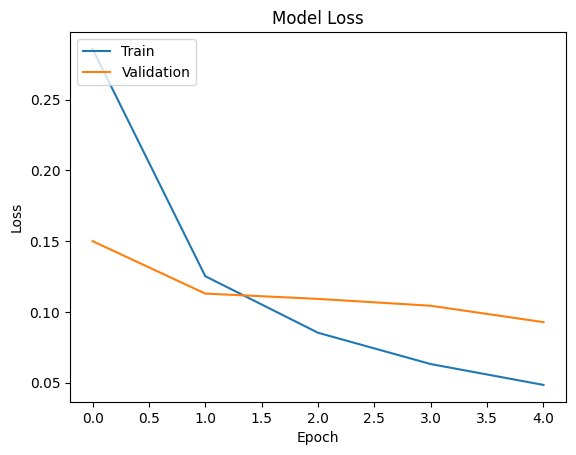

In [79]:
# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### 8. Detailed Evaluation: Confusion Matrix and Classification Report

In [81]:
predictions = model.predict(x_test)
# Convert predictions from probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Confusion Matrix:
[[ 966    0    2    1    1    3    4    1    2    0]
 [   0 1122    2    0    0    0    3    0    8    0]
 [   2    3  993   12    2    0    2    7   11    0]
 [   1    1    2  995    0    3    0    4    4    0]
 [   0    0    2    0  958    0   10    3    2    7]
 [   1    1    0   17    1  858    6    1    6    1]
 [   4    2    0    1    1    4  945    0    1    0]
 [   1    5    7    6    1    0    0 1003    2    3]
 [   1    0    2    9    3    1    3    3  951    1]
 [   2    5    0   14   17    4    1    9    8  949]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.94      0.99      0.96      1010
           4       0.97      0.98      0.97       982
           5       0.98      0.96      0.97       892
      

In [75]:
cm = confusion_matrix(y_test, y_pred)


**prompt:** plot confusion matrix

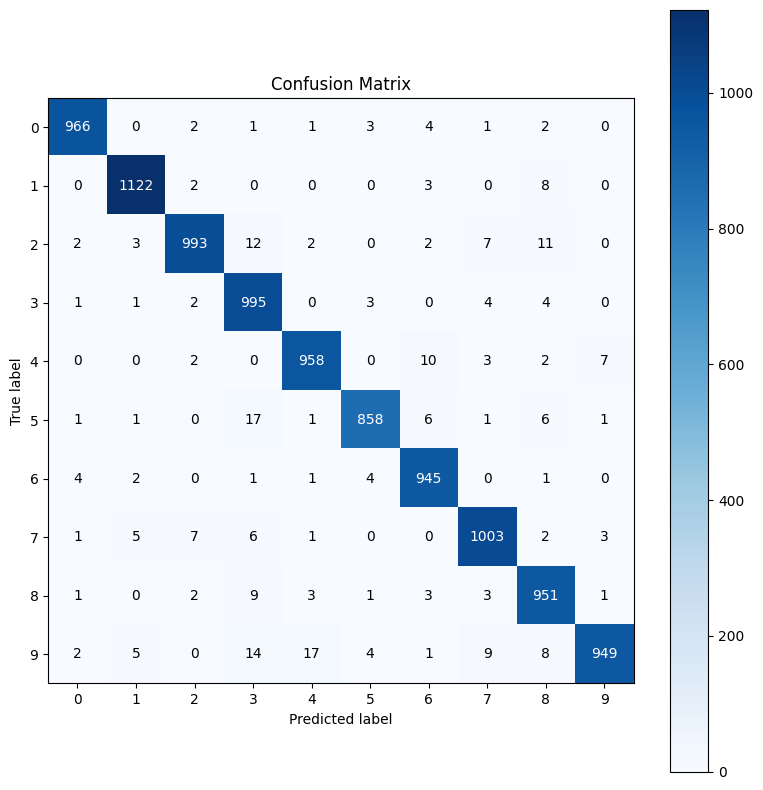

In [82]:
plt.figure(figsize=(8, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(cm.shape[0])
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Annotate each cell with the count
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

### View Mnist Data

**prompt:** plot mnist data

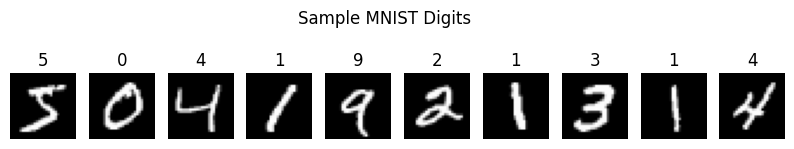

In [83]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

**prompt:** plot x_test and print predicted results

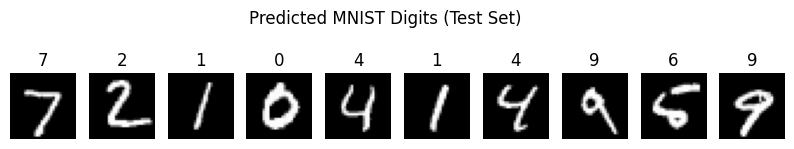

Predicted labels for first 10 test images: [7 2 1 0 4 1 4 9 6 9]


In [84]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(str(y_pred[i]))
    plt.axis('off')
plt.suptitle('Predicted MNIST Digits (Test Set)')
plt.show()
print("Predicted labels for first 10 test images:", y_pred[:10])

## Save Model

In [85]:
# Save the model in the native Keras format
model.save('67102010511_mnist_model.keras')
print("Model saved to mnist_model.keras")


Model saved to mnist_model.keras


## Restart Kernel/Session

## Load Model, Read Image and Predict

https://www.kaggle.com/datasets/scolianni/mnistasjpg

In [86]:
ls

67102010511_mnist_model.keras  img_1.jpg                  requirements.txt
app.py                         Intro-ANN-MNIST-std.ipynb  RubricsLabNN.pdf


In [88]:
# Load the saved model
model = tf.keras.models.load_model('67102010511_mnist_model.keras')
print("Model loaded successfully!")

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
The model predicts the digit is: 2


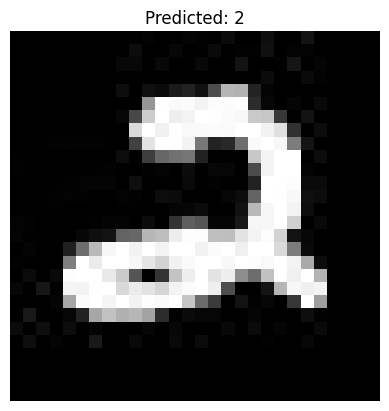

In [89]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# 1. Define the path to your image file
image_path = 'img_1.jpg' # Remember to upload 'image.jpg' to your Colab files!

try:
    # 2. Load the image using Pillow (PIL)
    img = Image.open(image_path)

    # 3. Convert the image to grayscale (MNIST images are grayscale)
    img = img.convert('L')

    # 4. Resize the image to 28x28 pixels, as required by the MNIST model
    img = img.resize((28, 28))

    # 5. Convert the image into a NumPy array
    img_array = np.array(img)

    # 6. Normalize the pixel values from [0, 255] to [0, 1]
    img_array = img_array.astype("float32") / 255.0

    # 7. Reshape the array to add a batch dimension (1 image, 28x28 pixels)
    # Our model expects input in the shape (batch_size, 28, 28)
    img_array = img_array.reshape(1, 28, 28)

    # 8. Use the trained model to make a prediction
    # The model outputs probabilities for each of the 10 digits
    prediction = model.predict(img_array)

    # 9. Get the predicted digit by finding the index of the highest probability
    predicted_digit = np.argmax(prediction)

    print(f"The model predicts the digit is: {predicted_digit}")

    # 10. Display the image with the predicted digit
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {predicted_digit}")
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: The image file '{image_path}' was not found. Please upload 'image.jpg' to your Colab environment by clicking the folder icon on the left sidebar, then the upload icon.")
except Exception as e:
    print(f"An unexpected error occurred: {e}. Please check the image format or content.")


## Create app.py - Streamlit

In [90]:
%%writefile app.py
import streamlit as st
from PIL import Image
import numpy as np
import tensorflow as tf # Assuming 'model' is a TensorFlow/Keras model
import os

st.title("MNIST Digit Predictor")
st.write("Upload an image of a handwritten digit to get a prediction.")

# Ensure the model is loaded (assuming 'model' is globally available or re-load it)
# If 'model' is not loaded, you would need to load it here, e.g., model = tf.keras.models.load_model('path/to/your/model.h5')
model_path = '67102010511_mnist_model.keras'
if not os.path.exists(model_path):
    st.error(f"Model file '{model_path}' not found. Please ensure the model is saved correctly.")
else:
    model = tf.keras.models.load_model(model_path)

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    try:
        # Load the image
        img = Image.open(uploaded_file)
        st.image(img, caption='Uploaded Image', use_column_width=True)
        st.write("")
        st.write("Classifying...")

        # Convert to grayscale
        img = img.convert('L')

        # Resize to 28x28 pixels
        img = img.resize((28, 28))

        # Convert to numpy array
        img_array = np.array(img)

        # Normalize pixel values to [0, 255] to [0, 1]
        img_array = img_array.astype("float32") / 255.0

        # Reshape for model prediction (add batch dimension)
        img_array = img_array.reshape(1, 28, 28)

        # Make a prediction
        prediction = model.predict(img_array)

        # Get the predicted digit
        predicted_digit = np.argmax(prediction)

        st.success(f"The model predicts the digit is: **{predicted_digit}**")

    except Exception as e:
        st.error(f"An error occurred during prediction: {e}. Please ensure the uploaded image is valid and the model is correctly loaded.")



Overwriting app.py


In [96]:
%%writefile requirements.txt
streamlit
Pillow
tensorflow==2.16.1
rich>=10.14.0

Overwriting requirements.txt


In [92]:
!python3 --version

Python 3.13.15


## Deployment

**ไปที่  https://github.com**

1.  สร้าง GitHub Repository

2. อัพโหลดไฟล์ใน GitHub Repository
ตรวจสอบให้แน่ใจว่าใน Repo ของคุณมีไฟล์ครบ 3 ไฟล์หลัก:

- app.py: ไฟล์โค้ดหน้าเว็บ Streamlit

- 6xxxx_mnist_model.keras: ไฟล์ Model ที่ Save ไว้

- requirements.txt: ไฟล์ระบุ Library ที่ต้องใช้ (เพื่อให้ Server ติดตั้ง Environment ได้ถูกต้อง)


**ไปที่ https://share.streamlit.io**

1. Sign in with GitHub เพื่อเชื่อมต่อบัญชี

2. คลิกปุ่ม "Create app" (หรือ "New app")

3. กรอกรายละเอียดดังนี้:

- Repository: เลือกชื่อ Repo ที่เพิ่งสร้าง

- Branch: ปกติจะเป็น main หรือ master

- Main file path: พิมพ์ app.py

4. คลิกปุ่ม "Deploy!"



**Problem Fix**

**ตรวจสอบสถานะการทำงาน** -->
สังเกตสถานะการ Deploy ที่มุมขวาล่าง (Manage app)


การจัดการ Python Version และการ Reboot
หากตรวจสอบ Logs แล้วพบว่า Library บางตัวติดตั้งไม่ผ่าน หรือ Code รันไม่ได้เนื่องจากความต่างของเวอร์ชัน ให้ลองใช้วิธีดังนี้:

**A. การเปลี่ยน Python Version (Advanced Settings)**
Streamlit Cloud มักจะใช้ Python เวอร์ชันล่าสุดเป็นค่าเริ่มต้น แต่หาก Model ของเราเทรนมาด้วยเวอร์ชันที่เก่ากว่า (เช่น Python 3.11 หรือ 3.12) เราสามารถปรับเปลี่ยนได้ที่:

- ในหน้า Dashboard ของ Streamlit ให้คลิกที่จุด 3 จุด (⋮) ข้างชื่อ App ของเรา

- เลือก Settings > Python Version

- เลือกเวอร์ชันที่ตรงกับเครื่องที่เราใช้เทรน (แนะนำ 3.10 หรือ 3.11 สำหรับเสถียรภาพสูงสุดกับ TensorFlow) ในงานนี้อาจลอง 3.12

- กด Save ระบบจะทำการลบ Environment เก่าและสร้างใหม่ให้ทันที

**B. การ Reboot App (ล้างไพ่ใหม่)**
- ในบางครั้งหลังจากเราแก้ไฟล์ requirements.txt บน GitHub แล้ว แต่ Server ยังจำค่าเดิมหรือค้าง (Cache) อยู่:

- ให้ไปที่เมนู Manage app (มุมขวาล่าง)

- คลิกจุด 3 จุดด้านบนของแถบ Logs แล้วเลือก Reboot app

- การ Reboot จะช่วยบังคับให้ Streamlit ติดตั้งทุกอย่างใหม่ตั้งแต่ต้น (Clean Install)



**ปรับแต่ง App**

- https://docs.streamlit.io/develop

- https://streamlit.io/gallery
